In [1]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_simulation(start_volume, feed_gap, ramp_factor):

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_gap
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate(S)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]    

exp_num = 0



def objective(trial):
    global exp_num
    exp_num += 1
    # Suggest values for each independent variable
    start_volume = trial.suggest_float('start_volume',0.0001  , 0.0009 )  # Volume in liters
    feed_gap = trial.suggest_float('feed_gap', 0.01 , 0.5  )  # Gap in hours
    ramp_factor = trial.suggest_float('ramp_factor', 0.001 , 0.5)  # Ramp factor

    # Run simulation with suggested values
    enzyme_activity = run_simulation(start_volume, feed_gap, ramp_factor)
    
    # Return enzyme activity as it is the metric we want to maximize
    return enzyme_activity


c:\Users\Reuel Group\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import optuna

def run_bayesopt(n_trials, n_runs):
    activities = []
    for _ in range(n_runs):
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials)
        activities.append(study.best_value)
    return activities


In [2]:
activities = []
parameters = []
for i in range(20):
    # Create a study and run optimization
    study = optuna.create_study(direction="maximize")  # We want to maximize enzyme activity
    study.optimize(objective, n_trials=125)  # Set the number of trials as needed

    activities.append(study.best_value)
    parameters.append(study.best_params)

print(activities)

[I 2025-02-09 21:11:08,218] A new study created in memory with name: no-name-e4863a46-8b57-46f9-8407-fc2ebbb90951
[I 2025-02-09 21:11:08,273] Trial 0 finished with value: 0.3803074876622333 and parameters: {'start_volume': 0.0002778993147388153, 'feed_gap': 0.178879392818033, 'ramp_factor': 0.17844881241574057}. Best is trial 0 with value: 0.3803074876622333.
[I 2025-02-09 21:11:08,282] Trial 1 finished with value: 0.0035227095771875327 and parameters: {'start_volume': 0.0005961640756306175, 'feed_gap': 0.06810264054708473, 'ramp_factor': 0.3713211613225442}. Best is trial 0 with value: 0.3803074876622333.
[I 2025-02-09 21:11:08,393] Trial 2 finished with value: 2.4591319095261444 and parameters: {'start_volume': 0.0004298225186721244, 'feed_gap': 0.45255406764991685, 'ramp_factor': 0.3237019860418521}. Best is trial 2 with value: 2.4591319095261444.
[I 2025-02-09 21:11:08,446] Trial 3 finished with value: 0.3956098790450793 and parameters: {'start_volume': 0.00016356058944493466, 'fee

[3.071084515486252, 3.0596309391629832, 3.1004839243878948, 3.0213953326626055, 2.81211801144044, 3.1593621229829445, 3.0008542851188915, 3.115568662024059, 3.1491534551754112, 3.1262718794455, 3.049641285872035, 3.0587662471956993, 3.0703678208765557, 3.00257452144806, 3.0701009961753405, 3.1106030001606078, 3.087020830632551, 3.154802371408062, 3.1472020769257685, 3.108648562761132]


In [3]:
indx = activities.index(max(activities))
best_parameters = parameters[indx]
print(best_parameters)
print(max(activities))

{'start_volume': 0.0007466646961794779, 'feed_gap': 0.12377761215446492, 'ramp_factor': 0.04790211436571709}
3.1593621229829445


In [4]:
best_params = best_parameters
best_start_volume = best_params['start_volume']
best_feed_gap = best_params['feed_gap']
best_ramp_factor = best_params['ramp_factor']

# Run final simulation with the best parameters, if needed
best_enzyme_activity = run_simulation(best_start_volume, best_feed_gap, best_ramp_factor)

print(f"Best Starting volume: {best_start_volume}")
print(f"Best Feeding Interval: {best_feed_gap}")
print(f"Best Ramp Factor: {best_ramp_factor}")
print("Enzyme activity with best parameters:", best_enzyme_activity)


Best Starting volume: 0.0007466646961794779
Best Feeding Interval: 0.12377761215446492
Best Ramp Factor: 0.04790211436571709
Enzyme activity with best parameters: 3.1593621229829445


Start flow volume 0.000785972404073766
Feed Interval 0.1701723516353244
Ramp Factor 0.0739859459733378
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  3.2133056573837617


<Figure size 700x500 with 0 Axes>

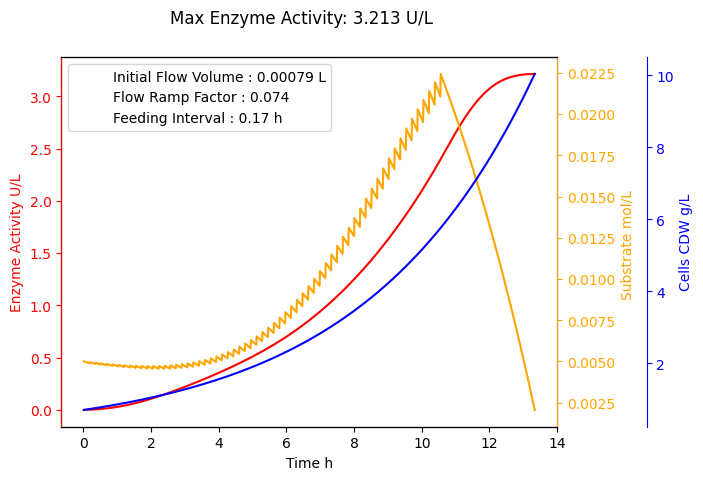

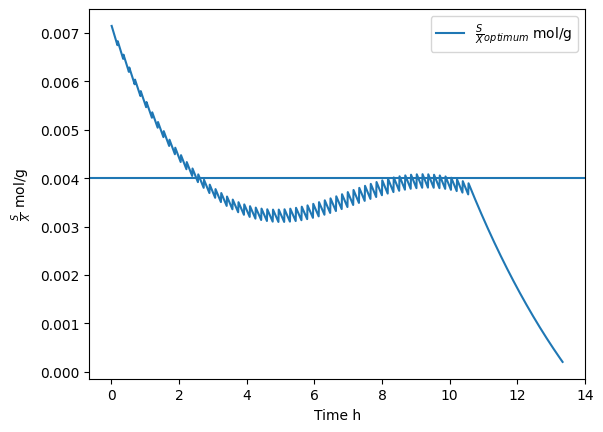

In [17]:
from matplotlib.lines import Line2D

start_flow_volume = best_start_volume
feed_interval = best_feed_gap
ramp_factor = best_ramp_factor

#print(f"------------- Experiment {index+1} ------------")
print(f"Start flow volume {start_flow_volume}")
print(f"Feed Interval {feed_interval}")
print(f"Ramp Factor {ramp_factor}")

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
plt.figure(figsize=(7,5))
max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)
print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.18))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time h")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Initial Flow Volume : {round(start_flow_volume,5)} L'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Flow Ramp Factor : {round(ramp_factor,3)}'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Feeding Interval : {round(feed_interval,3)} h'),

]

# Add the custom legend
plt.legend(handles=custom_lines)
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label=r"$\frac{S}{X}_{optimum}$ mol/g")
plt.axhline(y=config.OPT_SUB_CELL_RATIO)
plt.xlabel("Time h")
plt.ylabel(r"$\frac{S}{X}$ mol/g")
plt.legend()